This is firs assignment (out of three). 

Submission guideline:

- Total point- 100 

- Attend all questions.

- Upload a zip/rar file containing the following:

    - MAS512_assignment1_gr#.py or MAS512_assignment1_gr#.ipynb. These files should be error free.

    - Each questions should be done in a cell, such that when I run the cell - I get the outputs.
    
    - MAS512_assignment1_gr#.ppt explaining the objective, method and results of each questions. 
    
    - Make   the presentation clear, readable, precise and attractive.

- Each group will be given 10 min to present the assignment followed by 5 minutes of Q/A. The presentation takes place in Lab, and all students are expected to attend peer's presentation

- Assignment is graded based on problem solving skills, work break down, algorithms, code, powerpoint and presentation

- Students are expected to solve the problem themselves.

- You can use LLM generative models as 'help', understand the working and algorithm, modify and use them.

- Be specific and precise when you write code, make powerpoint and present assignment

# Q1. Object detection and depth estimation                             20+5+20 = 45 points
 Use L515 camera in Lab to acquire rgb video and depth video (e.g. 30 s) of swinging load in lab (rgb_train_val_swingingload.avi; depth_train_val_swingingload.avi). Extract each frames from rgb video. Use the extracted images to train and validate YOLO model (save as YOLO_swinging_load.pt). Record test_swingingload.avi (e.g. 5 s). Extract frames and use them as test data set. Test your YOLO model (YOLO_swinging_load.pt) on this test data set.

(a) Show the performance of your model on test data set by plotting relevant KPIs.

(b) Sample five random images from test data video (test_swingingload.avi). Find the center, and coordinates of bounding box. Display them on the each test image.

(c) realsense_acq.ipynb contains code that streams, rgb, and depth video. Based on this code, extract the frames from depth_train_val_swingingload.avi. Each pixel in each frame consists of depth information of corresponding rgb images. As described in Q1.b find the center of bounding box of ALL frames in  test video (test_swingingload.avi). Display its center and corresponding depth.


References: Use Ultralytics framework for help - https://docs.ultralytics.com/tasks/detect
Realsense - https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/ 

# Q2. Object tracking                                                           5 points
  Perform tracking of swinging load on test_swingingload.avi. You should display the trajectory of load as it swings each frame as shown in Fig. below. 

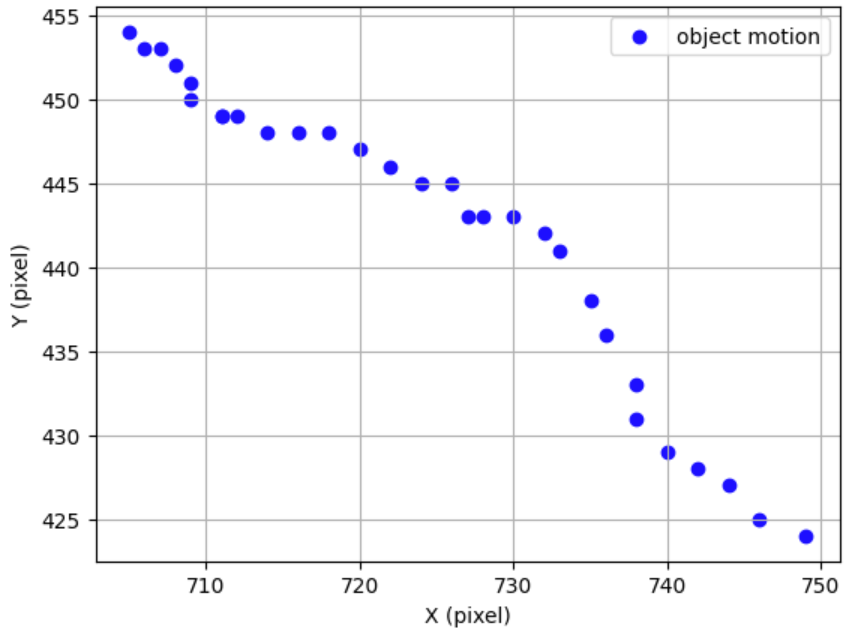

Ref: Use help from Ultralytics - https://docs.ultralytics.com/guides/instance-segmentation-and-tracking 

# Q3. Multi object segmentation, tracking and counting:                         10  points

Explore different data-set available freely on internet (https://docs.ultralytics.com/datasets ). Get familiar with them. Then choose a data set and corresponding class of your choice (e.g. CICAR-10 dataset/COCO data set or KITTI data set / person). Then make a video such that multiple instances of objects are in the scene (e.g. 5 people are the scene). Perform 
(a) instance segmentation, 
(b) counting  - total number of object in scene
(c) and tracking of individual instance of object
(d) draw a region - and count the object in that region


# Q4. Classification                                                        10  marks
Given the data-set fault-classification-class. Perform the following
(a) Develop ML model to determine the state of health of asset (in this case motor).
(b) Show, train and val loss, confusion matrix and classification report
(c) Consider the one in the class as baseline and compare your model with it. Summarize in terms of
model parameter, inference time, accuracy, precision, recall, F1 score

# Q5. Classification                                                        20  
Download CFAR-10 dataset (https://www.tensorflow.org/datasets/catalog/cifar10). Perform the classification task on this dataset 
(a) Use model fusion (use two or models to extract feature and combine them), 
(b) Use transfer learning
(c) Use finetuning
(d) Compare different methods (a) - (c) in terms of typical KPIs often used for classification

# Q6. Autoencoder                                                           10 marks
Given the data-set fault-classification-class, 
Use Auto encoder to compress the data to latent space and reconstruct it back. Show the following for random 10 iamges from each class
(a) Original image
(b) Latent vector
(c) Reconstructed back image
(d) individual reconstruction error and mean loss for each class.


Q1
Detection - Find the object in scene
3D - RGB image

1. Film rgb_train_val_swingingload.avi

2. trekk ut frames: Open CV
https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/
https://opencv.org/reading-and-writing-videos-using-opencv/#h-import-cv2

3. annoter lasten
4. tren egen YOLO-modell
5. lagre modellen som YOLO_swinging_load.pt
6. kjør den på test_swingingload.avi

In [ ]:
#https://github.com/hedheddaw-stack/MAS512_Group9 - Github-link
from pathlib import Path
from ultralytics import YOLO
import shutil
import yaml

# Main project folder
project_folder = Path.cwd()

# Dataset folders
data_folder = project_folder / "Data"

train_folder = data_folder / "Train"
test_folder = data_folder / "Test"

# Fall back to the original recording-session folders if the data has not been copied into Data/
if not (train_folder / "rgb_frames").exists():
    session_folder = project_folder / "data_assignment1_q1" / "data"
    train_folder = session_folder / "session_20260918_152400_train"
    test_folder = session_folder / "session_20260918_152832_test"

# RGB data
train_rgb = train_folder / "rgb_frames"
test_rgb = test_folder / "rgb_frames"

# Depth data
test_depth = test_folder / "depth_raw"
depth_scale_file = test_folder / "depth_scale_json" / "depth_scale.json"

# Files used during our YOLO workflow
annotation_file = project_folder / "swingingload30.ndjson"
dataset_yolo = project_folder / "Dataset_YOLO"
selectedtraining_frames = train_folder / "rgb_selected"
trained_model_file = project_folder / "YOLO_swinging_load.pt"

# Count the available RGB frames
number_train_frames = len(list(train_rgb.glob("*.png")))
number_test_frames = len(list(test_rgb.glob("*.png")))

print("Dataset successfully found!")
print("You now have the following RGB frames:")
print("Training RGB frames:", number_train_frames)
print("Testing RGB frames:", number_test_frames)

Dataset successfully found!
You now have the following RGB frames:
Training RGB frames: 900
Testing RGB frames: 300


In [2]:
# Selection of 30 pictures

selectedtraining_frames.mkdir(parents=True, exist_ok=True)

image_files = sorted(train_rgb.glob("*.png"))

# Select 30 evenly distributed frames from the training video. This is important because we want to ensure that the selected frames represent the entire video and not just a specific segment. By selecting frames at regular intervals, we can capture a diverse set of images that cover different parts of the video. This is crucial for training a robust model that can generalize well to new data.
selected_files = image_files[::30]

for image_path in selected_files:
    shutil.copy(
        image_path,
        selectedtraining_frames / image_path.name
    )

print("Selected images:", len(selected_files))

Selected images: 30


In [3]:
# convert_ndjson_to_yolo turns the Ultralytics-platform annotation export (.ndjson) into YOLO folders.
# It is an async function (it downloads the images), so it has to be called with 'await'.
from ultralytics.data.converter import convert_ndjson_to_yolo

yaml_path = await convert_ndjson_to_yolo(
    str(annotation_file),
    output_path=str(dataset_yolo)
)

print("YOLO dataset:", yaml_path)

YOLO dataset: c:\Users\resjw\Downloads\Dataset_YOLO\swingingload30-592ad8ef\data.yaml


In [4]:
# Check which classes are included in the converted YOLO dataset
with open(yaml_path) as file:
    dataset_config = yaml.safe_load(file)

print("Classes:", dataset_config["names"])

Classes: {0: 'Class 0', 1: 'swinging_load'}


In [5]:
#Transfer Learning: Loading the pretrained Ultralytics YOLO26n model and train it on the selected images

model = YOLO("yolo26n.pt")


In [25]:
# Train the model on the selected and annotated images
# The model is trained for 100 epochs with an image size of 640 pixels.
# Training takes ~15 min on CPU, so it is skipped when YOLO_swinging_load.pt already exists
# (delete that file to train again). Training curves are saved by Ultralytics in runs/detect/train*/.

if trained_model_file.exists():
    print("Found", trained_model_file.name, "- skipping training")
else:
    results = model.train(
        data=yaml_path,
        epochs=100,
        imgsz=640
    )
    best_weights = Path(results.save_dir) / "weights" / "best.pt"
    shutil.copy(best_weights, trained_model_file)

New https://pypi.org/project/ultralytics/8.4.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.158  Python-3.10.11 torch-2.14.0+cpu CPU (11th Gen Intel Core i7-11370H @ 3.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\hedhe\MAS512_Group9\Dataset_YOLO\swingingload30-3822835c\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, ma

KeyboardInterrupt: 

In [7]:
# Load the best trained model weights for all inference below

trained_model = YOLO(trained_model_file)

print("The saved trained model is:", trained_model_file.name)

The saved trained model is: YOLO_swinging_load.pt


## Q1(a): Model performance on the test data set

`test_swingingload.avi` has no ground-truth boxes (only the 30 training frames were annotated), so
classic precision/recall/mAP can't be computed on it directly. Instead we run the trained model over
every test frame and report practical KPIs: detection confidence, how many frames actually get a
detection, and inference speed.

If you also annotate the test frames later and build a `data.yaml` for them, swap in
`trained_model.val(data=..., split="test")` instead — that gives the standard mAP/PR-curve/
confusion-matrix plots Ultralytics produces during training.


Performance evaluation: Validation performance: Precision, Recall, F1, mAP50, mAP50-95

In [8]:
# Evaluate the trained YOLO model

metrics = trained_model.val(
    data=yaml_path
)

Ultralytics 8.4.162  Python-3.10.11 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-13450HX)
YOLO26n summary (fused): 120 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 128.852.0 MB/s, size: 84.1 KB)
val: Scanning C:\Users\resjw\Downloads\Dataset_YOLO\swingingload30-592ad8ef\labels\val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.7it/s 0.3s
                   all          6          6      0.988      0.833      0.931      0.762
         swinging_load          6          6      0.988      0.833      0.931      0.762
Speed: 1.2ms preprocess, 32.8ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to C:\Users\resjw\Downloads\runs\detect\val-5


In [9]:
# Main YOLO performance metrics

precision = metrics.box.mp
recall = metrics.box.mr
f1_score = metrics.box.f1[0]
map50 = metrics.box.map50
map50_95 = metrics.box.map

print("YOLO model performance:")
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 score:", round(f1_score, 3))
print("mAP50:", round(map50, 3))
print("mAP50-95:", round(map50_95, 3))

YOLO model performance:
Precision: 0.988
Recall: 0.833
F1 score: 0.904
mAP50: 0.931
mAP50-95: 0.762


Performance when running the trained model on the 300 test-video frames: confidence, frames with no detection, latency and FPS.

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

#Testing the trained YOLO model on the test images and measuring inference time, confidence values, and detections per frame

test_images = sorted(test_rgb.glob("*.png"))

confidence_values = []
detections_per_frame = []
inference_times = []

for image_path in test_images:

    start_time = time.perf_counter()

    prediction = trained_model.predict(
        source=str(image_path),
        verbose=False
    )[0]

    inference_time = (time.perf_counter() - start_time) * 1000
    inference_times.append(inference_time)

    if prediction.boxes is not None:
        frame_confidence = prediction.boxes.conf.cpu().numpy()
    else:
        frame_confidence = np.array([])

    confidence_values.extend(frame_confidence.tolist())
    detections_per_frame.append(len(frame_confidence))

Test video performance:
Mean confidence: 0.733
Frames that did not get detected: 15 / 300
Mean inference time: 51.1 ms
Approximate FPS: 19.6


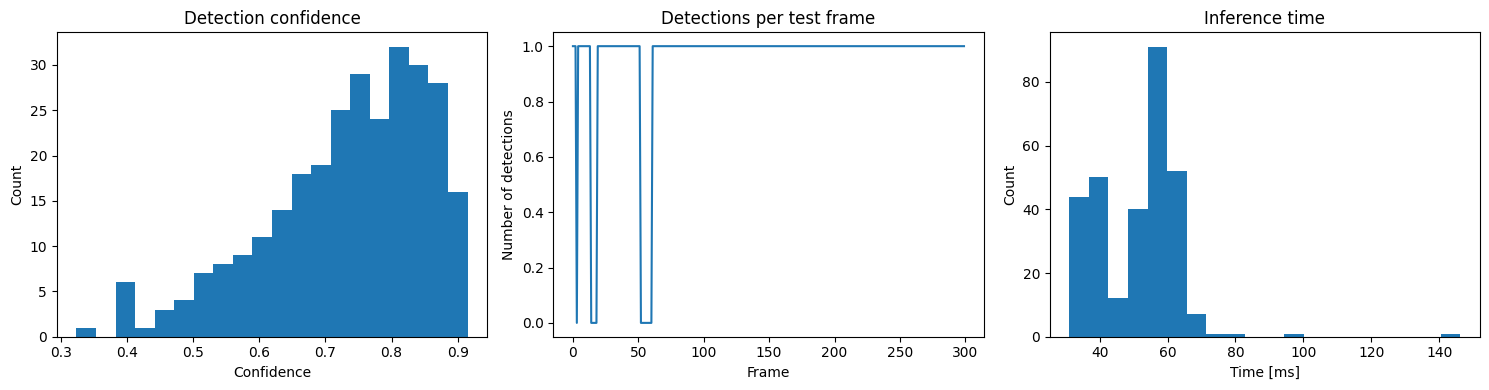

In [11]:
# Calculate test-video performance values

mean_confidence = np.mean(confidence_values)
no_detection_frames = detections_per_frame.count(0)
mean_inference_time = np.mean(inference_times)
fps = 1000 / mean_inference_time

print("Test video performance:")
print("Mean confidence:", round(mean_confidence, 3))
print("Frames that did not get detected:", no_detection_frames, "/", len(test_images))
print("Mean inference time:", round(mean_inference_time, 1), "ms")
print("Approximate FPS:", round(fps, 1))


# Plot the results

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(confidence_values, bins=20)
axes[0].set_title("Detection confidence")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")

axes[1].plot(detections_per_frame)
axes[1].set_title("Detections per test frame")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Number of detections")

axes[2].hist(inference_times, bins=20)
axes[2].set_title("Inference time")
axes[2].set_xlabel("Time [ms]")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Q1(b): Bounding box center on 5 random test images


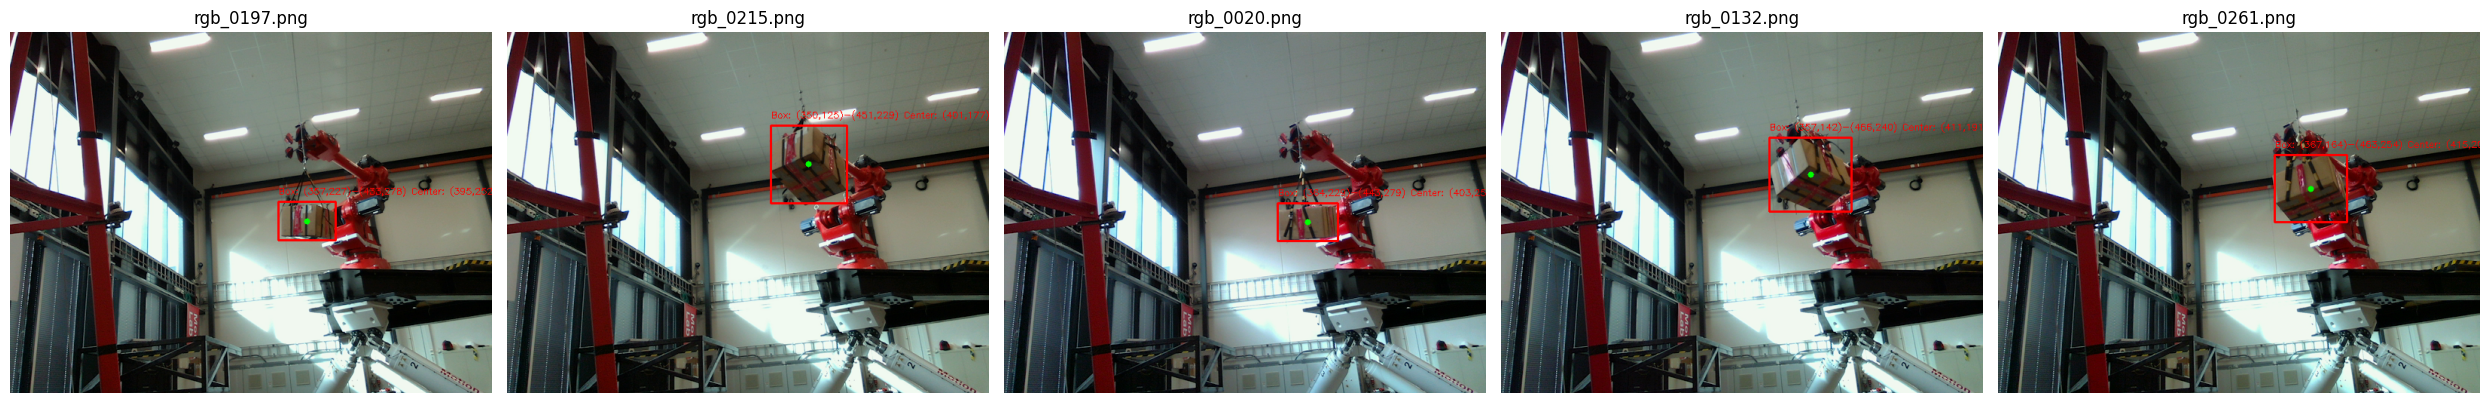

In [12]:
import random
import cv2
import matplotlib.pyplot as plt

random.seed(0)
sample_paths = random.sample(test_images, 5)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, img_path in zip(axes, sample_paths):

    result = trained_model.predict(
        source=str(img_path),
        verbose=False
    )[0]

    img = cv2.cvtColor(
        cv2.imread(str(img_path)),
        cv2.COLOR_BGR2RGB
    )

    for box in result.boxes:

        #Bounding box coordinates for detected object
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        # Calculate center point
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        #Drawing bounding box and center point
        cv2.rectangle(
            img,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (255, 0, 0),
            2
        )

        cv2.circle(
            img,
            (int(cx), int(cy)),
            4,
            (0, 255, 0),
            -1
        )

        # Display bounding box and center coordinates
        label = (
            f"Box: ({x1:.0f},{y1:.0f})-({x2:.0f},{y2:.0f}) "
            f"Center: ({cx:.0f},{cy:.0f})"
        )

        cv2.putText(
            img,
            label,
            (int(x1), max(int(y1) - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 0, 0),
            1
        )

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Q1(c): Depth at the bounding box center for all test frames

Each `rgb_XXXX.png` frame has an index-aligned `depth_XXXX_raw.npy` file (raw uint16 depth, aligned to
the color frame during acquisition — see `realsense_acq.ipynb`). Multiplying the raw value by
`depth_scale` from `depth_scale.json` converts it to meters.


{'frame': '0000', 'center_x': 399.98193359375, 'center_y': 190.43807983398438, 'depth_m': 0.0}
{'frame': '0001', 'center_x': 417.27581787109375, 'center_y': 243.97691345214844, 'depth_m': 0.0}
{'frame': '0002', 'center_x': 417.02740478515625, 'center_y': 248.12347412109375, 'depth_m': 3.512750166846672}
{'frame': '0004', 'center_x': 417.20123291015625, 'center_y': 251.28628540039062, 'depth_m': 3.735250177414855}
{'frame': '0005', 'center_x': 420.9112548828125, 'center_y': 252.60476684570312, 'depth_m': 3.8217501815233845}
Detected in 285 / 300 frames


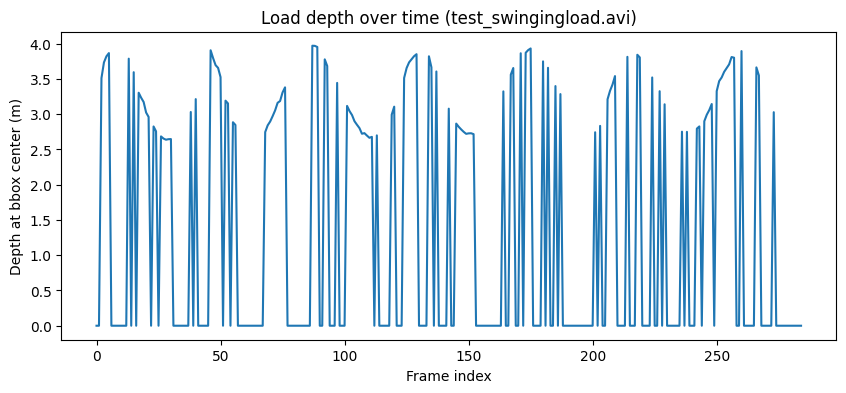

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(depth_scale_file) as f:
    depth_scale = json.load(f)["depth_scale"]

records = []

for img_path in test_images:
    frame_idx = img_path.stem.split("_")[-1]  # "rgb_0000" -> "0000"
    depth_path = test_depth / f"depth_{frame_idx}_raw.npy"

    result = trained_model.predict(source=str(img_path), verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    # Highest-confidence detection = the load, for frames with multiple detections
    best_idx = int(result.boxes.conf.argmax())

    x1, y1, x2, y2 = result.boxes.xyxy[best_idx].cpu().numpy()
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

    depth_raw = np.load(depth_path)

    row = min(max(int(round(cy)), 0), depth_raw.shape[0] - 1)
    col = min(max(int(round(cx)), 0), depth_raw.shape[1] - 1)

    depth_m = float(depth_raw[row, col]) * depth_scale

    records.append({
        "frame": frame_idx,
        "center_x": cx,
        "center_y": cy,
        "depth_m": depth_m
    })

for r in records[:5]:
    print(r)

print(f"Detected in {len(records)} / {len(test_images)} frames")

depth_values = [r["depth_m"] for r in records]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(len(depth_values)), depth_values)

ax.set_xlabel("Frame index")
ax.set_ylabel("Depth at bbox center (m)")
ax.set_title("Load depth over time (test_swingingload.avi)")

plt.show()


# Q2. Object tracking — trajectory of the swinging load

Runs `trained_model.track(..., persist=True)` frame-by-frame over the test frames (the pattern
Ultralytics recommends for looping over a frame sequence) and plots the bounding-box center of each
frame as a scatter, matching the reference trajectory plot (`Q2_example.png`) from the class materials.


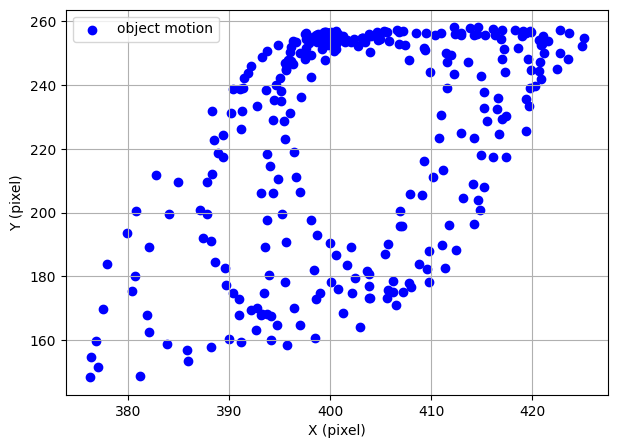

In [14]:
import matplotlib.pyplot as plt

track_xs, track_ys = [], []

for img_path in test_images:
    result = trained_model.track(source=str(img_path), persist=True, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        continue
    best_idx = int(result.boxes.conf.argmax())
    x1, y1, x2, y2 = result.boxes.xyxy[best_idx].cpu().numpy()
    track_xs.append((x1 + x2) / 2)
    track_ys.append((y1 + y2) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(track_xs, track_ys, color="blue", label="object motion")
ax.set_xlabel("X (pixel)")
ax.set_ylabel("Y (pixel)")
ax.legend()
ax.grid(True)
plt.show()


# Q3. Multi object segmentation, tracking and counting

**Dataset explored:** KITTI (Ultralytics `kitti.yaml` / `kitti.ndjson`), a 2D autonomous-driving detection dataset
with 8 classes (car, van, truck, pedestrian, person_sitting, cyclist, tram, misc). **Class chosen:** vehicles.
**Video:** `biler.mp4`, a roadside traffic camera (E18 Fiskevollbukta) with several vehicles in the scene at once.

Plan (same Ultralytics workflow as the class notebook `instance-segment-tracking-class.ipynb`):
1. Train a YOLO detector on a subset of KITTI (190 images containing cars, 20 epochs). The full 6k-image dataset
   is too slow on a CPU. The model is then tested on `biler.mp4`.
2. KITTI only has bounding boxes and no masks, so a model trained on it cannot do segmentation. Q3 (a)-(d) therefore
   use a **pretrained YOLO26s-seg** model (trained on COCO, whose classes include car/bus/truck).

In [15]:
from pathlib import Path
from ultralytics import YOLO, solutions
import shutil
import json
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

KITTI_NDJSON_PATH = project_folder / "kitti.ndjson"
BILER_VIDEO_PATH = project_folder / "biler.mp4"
KITTI_SUBSET_PATH = project_folder / "kitti_car_subset.ndjson"
KITTI_DATASET_YOLO_DIR = project_folder / "Dataset_KITTI"
KITTI_MODEL_PATH = project_folder / "YOLO_kitti_car.pt"

assert KITTI_NDJSON_PATH.exists(), f"Missing {KITTI_NDJSON_PATH}"
assert BILER_VIDEO_PATH.exists(), f"Missing {BILER_VIDEO_PATH}"

In [16]:
# Subset of KITTI: images that contain at least one car (150 train / 40 val)
random.seed(0)

with open(KITTI_NDJSON_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

header = lines[0]
image_records = [json.loads(line) for line in lines[1:]]

car_images = [
    r for r in image_records
    if any(b[0] == 0 for b in r.get("annotations", {}).get("boxes", []))
]
print(f"Images containing at least one car: {len(car_images)} / {len(image_records)}")

train_imgs = [r for r in car_images if r.get("split") == "train"]
val_imgs = [r for r in car_images if r.get("split") == "val"]
random.shuffle(train_imgs)
random.shuffle(val_imgs)

N_TRAIN, N_VAL = 150, 40
subset = train_imgs[:N_TRAIN] + val_imgs[:N_VAL]

with open(KITTI_SUBSET_PATH, "w", encoding="utf-8") as f:
    f.write(header)
    for rec in subset:
        f.write(json.dumps(rec) + "\n")

print(f"Subset: {len(subset)} images ({N_TRAIN} train / {N_VAL} val) -> {KITTI_SUBSET_PATH.name}")

Images containing at least one car: 6684 / 7481
Subset: 190 images (150 train / 40 val) -> kitti_car_subset.ndjson


In [17]:
# convert_ndjson_to_yolo turns the Ultralytics-platform annotation export (.ndjson) into YOLO folders.
# It is an async function (it downloads the images), so it has to be called with 'await'.
# Train YOLO26n on the KITTI subset (~18 min on CPU). Skipped when YOLO_kitti_car.pt already exists.
from ultralytics.data.converter import convert_ndjson_to_yolo

kitti_yaml_path = await convert_ndjson_to_yolo(
    str(KITTI_SUBSET_PATH),
    output_path=str(KITTI_DATASET_YOLO_DIR)
)
with open(kitti_yaml_path) as f:
    print("Classes in KITTI subset:", yaml.safe_load(f)["names"])

if KITTI_MODEL_PATH.exists():
    print("Found", KITTI_MODEL_PATH.name, "- skipping training")
else:
    kitti_results = YOLO("yolo26n.pt").train(data=kitti_yaml_path, epochs=20, imgsz=640)
    shutil.copy(Path(kitti_results.save_dir) / "weights" / "best.pt", KITTI_MODEL_PATH)

kitti_trained_model = YOLO(KITTI_MODEL_PATH)

# Validation KPIs of the KITTI model (40 val images)
kitti_metrics = kitti_trained_model.val(data=kitti_yaml_path, verbose=False)
print(f"KITTI val: precision={kitti_metrics.box.mp:.3f}  recall={kitti_metrics.box.mr:.3f}  "
      f"mAP50={kitti_metrics.box.map50:.3f}  mAP50-95={kitti_metrics.box.map:.3f}")

Classes in KITTI subset: {0: 'car', 1: 'van', 2: 'truck', 3: 'pedestrian', 4: 'person_sitting', 5: 'cyclist', 6: 'tram', 7: 'misc'}
Found YOLO_kitti_car.pt - skipping training
Ultralytics 8.4.162  Python-3.10.11 torch-2.14.0+cpu CPU (13th Gen Intel Core i5-13450HX)
YOLO26n summary (fused): 120 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 171.558.6 MB/s, size: 104.0 KB)
val: Scanning C:\Users\resjw\Downloads\Dataset_KITTI\kitti_car_subset-54816d98\labels\val.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s1.1s
                   all         40        256      0.511      0.247      0.219      0.133
Speed: 0.8ms preprocess, 19.2ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to C:\Users\resjw\Downloads\runs\detect\val-6
KITTI val: precision=0.511  recall=0.247  mA

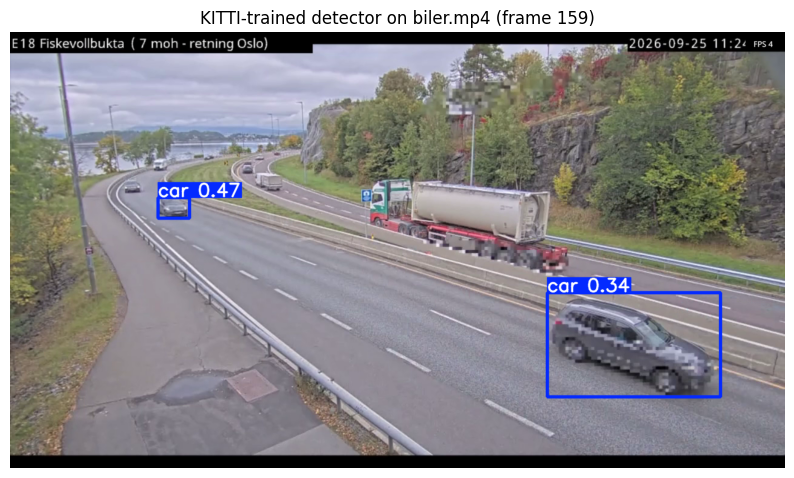

In [18]:
# Test the KITTI-trained detector on a frame from biler.mp4
cap = cv2.VideoCapture(str(BILER_VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, 159)
ok, demo_frame = cap.read()
cap.release()

demo_result = kitti_trained_model.predict(source=demo_frame, verbose=False)[0]

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(demo_result.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("KITTI-trained detector on biler.mp4 (frame 159)")
plt.show()

## Q3(a): Instance segmentation

Pretrained `yolo26s-seg.pt`, restricted to the COCO vehicle classes **car (2), bus (5) and truck (7)**. Filtering on `car`
only would drop the trucks and buses in the video. `imgsz=1280` keeps the full camera resolution, so small cars far
down the road are still detected, and `conf=0.15` keeps the weaker detections of distant vehicles.

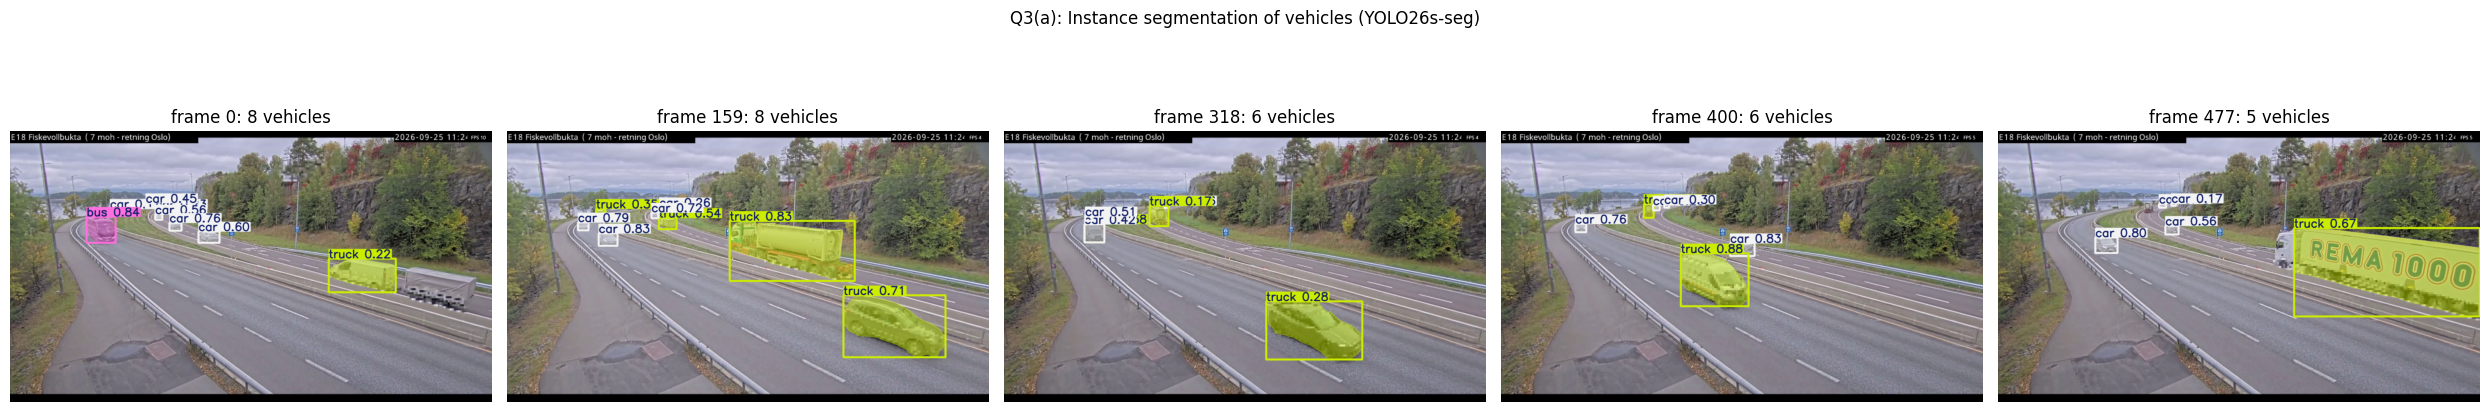

In [19]:
seg_model = YOLO("yolo26s-seg.pt")
VEHICLE_CLASSES = [2, 5, 7]   # COCO: car, bus, truck
CONF = 0.15
IMGSZ = 1280

cap = cv2.VideoCapture(str(BILER_VIDEO_PATH))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample_idxs = [0, 159, 318, 400, 477]

fig, axes = plt.subplots(1, len(sample_idxs), figsize=(25, 5))
for ax, idx in zip(axes, sample_idxs):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    result = seg_model.predict(frame, classes=VEHICLE_CLASSES, conf=CONF, imgsz=IMGSZ, verbose=False)[0]
    ax.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}: {len(result.boxes)} vehicles")
    ax.axis("off")
cap.release()

plt.suptitle("Q3(a): Instance segmentation of vehicles (YOLO26s-seg)")
plt.tight_layout()
plt.show()

## Q3(b) + (c): Counting and tracking individual vehicles

`biler.mp4` is a traffic-camera stream: the file is saved at 47 fps, but the camera only sends a new image about
3 times per second, so most frames are exact copies. Only frames that differ from the previous kept frame are
processed (mean absolute pixel difference > 2). This is not just for speed. We tested tracking on all 637 frames:
it took 5.5 min instead of 35 s and split vehicles into 53 short IDs instead of 15. The copies make a vehicle
stand still and then jump, and the tracker loses it.

For the same reason the default tracker settings lose vehicles between camera images, so a ByteTrack configuration
(`q3_tracker.yaml`) is used: lower detection thresholds, more lenient box matching (`match_thresh=0.95`), and a lost
track is kept for 15 processed frames.

In [20]:
# ByteTrack settings for a low-frame-rate traffic camera (see markdown above)
TRACKER_CFG = project_folder / "q3_tracker.yaml"
TRACKER_CFG.write_text(
    "tracker_type: bytetrack\n"
    "track_high_thresh: 0.15\n"
    "track_low_thresh: 0.05\n"
    "new_track_thresh: 0.15\n"
    "track_buffer: 15\n"
    "match_thresh: 0.95\n"
    "fuse_score: True\n"
)

# Read the video and keep only frames that differ from the previously kept frame.
# The image is an array of pixel intensities, so the difference is the mean absolute pixel difference.
cap = cv2.VideoCapture(str(BILER_VIDEO_PATH))
frames = []        # new camera images
frame_idxs = []    # their index in the video
previous_gray = None
i = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    if previous_gray is None or np.abs(gray - previous_gray).mean() > 2.0:
        frames.append(frame)
        frame_idxs.append(i)
        previous_gray = gray
    i += 1
cap.release()
print(f"{len(frames)} new camera images out of {total_frames} video frames")

# Track the vehicles on the new camera images
seg_model = YOLO("yolo26s-seg.pt")  # fresh model so the tracker starts from zero
frame_counts = []     # number of vehicles in each frame
track_history = {}    # track ID -> list of box centres (x, y)

for frame in frames:
    result = seg_model.track(frame, classes=VEHICLE_CLASSES, conf=CONF, imgsz=IMGSZ,
                             persist=True, tracker=str(TRACKER_CFG), verbose=False)[0]
    frame_counts.append(len(result.boxes))
    if result.boxes.id is not None:
        track_ids = result.boxes.id.int().cpu().tolist()
        boxes = result.boxes.xywh.cpu().numpy()      # centre x, centre y, width, height
        for track_id, box in zip(track_ids, boxes):
            if track_id not in track_history:
                track_history[track_id] = []
            track_history[track_id].append((float(box[0]), float(box[1])))

# a vehicle counts as tracked when it was followed for at least 3 camera images
tracked_vehicles = {}
for track_id, points in track_history.items():
    if len(points) >= 3:
        tracked_vehicles[track_id] = points

print(f"Total unique vehicles tracked: {len(tracked_vehicles)}")
print(f"Max vehicles in a single frame: {max(frame_counts)}")
print(f"Mean vehicles per frame: {np.mean(frame_counts):.1f}")

52 new camera images out of 637 video frames
Total unique vehicles tracked: 14
Max vehicles in a single frame: 8
Mean vehicles per frame: 3.9


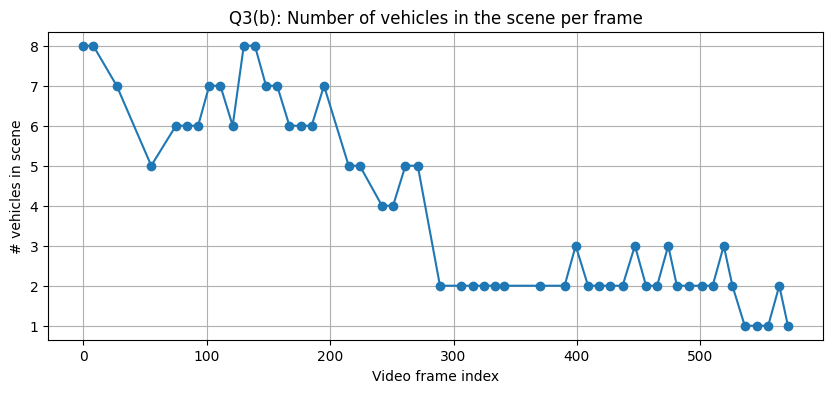

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(frame_idxs, frame_counts, "-o")
plt.xlabel("Video frame index")
plt.ylabel("# vehicles in scene")
plt.title("Q3(b): Number of vehicles in the scene per frame")
plt.grid(True)
plt.show()

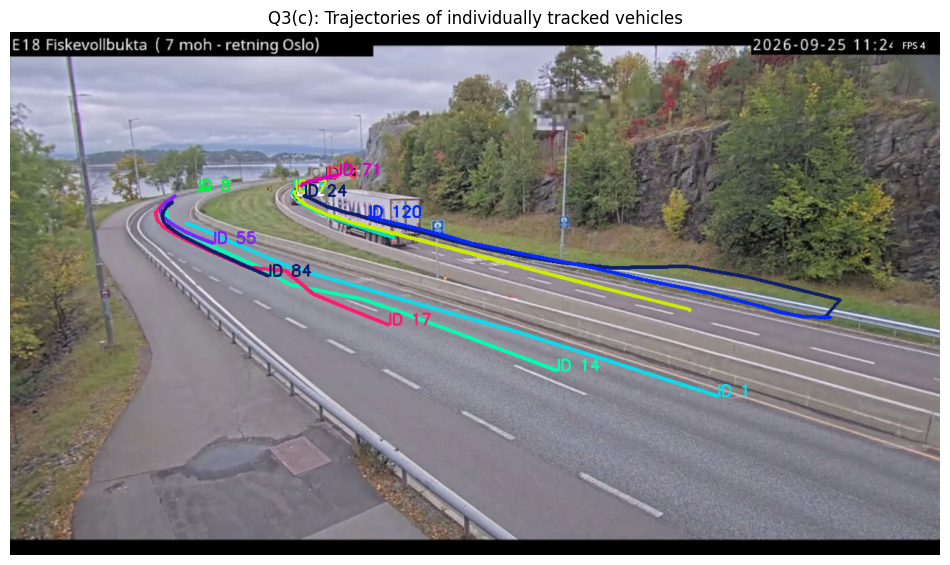

In [22]:
# Q3(c): trajectory of each tracked vehicle drawn on the last frame
from ultralytics.utils.plotting import colors   # same colour per ID as Ultralytics uses

background = frames[-1].copy()
for track_id, points in tracked_vehicles.items():
    color = colors(track_id, True)
    points = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
    cv2.polylines(background, [points], isClosed=False, color=color, thickness=3)
    cv2.putText(background, f"ID {track_id}", tuple(points[-1][0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Q3(c): Trajectories of individually tracked vehicles")
plt.show()

## Q3(d): Region counting

The region is a polygon across both carriageways, where the vehicles are large enough to be detected reliably.
It is counted with Ultralytics `solutions.RegionCounter` (the `solutions` module imported in the class notebook).
This counts, in every frame, the vehicles whose box centre lies inside the region.

Ultralytics Solutions:  {'source': None, 'model': 'yolo26s-seg.pt', 'classes': [2, 5, 7], 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': [(170, 270), (1280, 270), (1280, 470), (290, 470)], 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.15, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 1280, 'tracker': 'c:\\Users\\resjw\\Downloads\\q3_tracker.yaml', 'verbose': False, 'data': 'images'}
WARNING No tracks found.
WARNING No tracks found.
Max vehicles inside the region at once: 3
Mean vehicles inside the region: 1.33


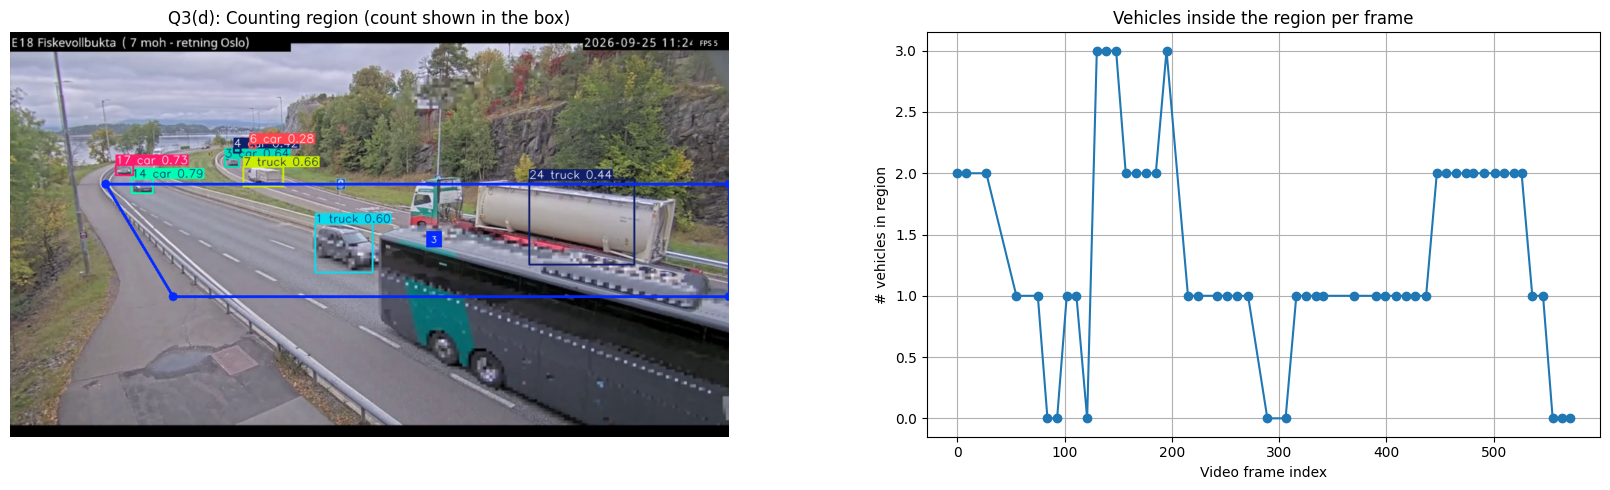

In [23]:
region_points = [(170, 270), (1280, 270), (1280, 470), (290, 470)]

region_counter = solutions.RegionCounter(
    model="yolo26s-seg.pt",
    region=region_points,
    classes=VEHICLE_CLASSES,
    conf=CONF,
    imgsz=IMGSZ,
    tracker=str(TRACKER_CFG),
    show=False,
    verbose=False,
)

region_counts = []
example_frame = None
for frame in frames:
    res = region_counter(frame.copy())
    n_in_region = sum(res.region_counts.values())
    region_counts.append(n_in_region)
    if example_frame is None or n_in_region > max(region_counts[:-1]):
        example_frame = res.plot_im

print(f"Max vehicles inside the region at once: {max(region_counts)}")
print(f"Mean vehicles inside the region: {np.mean(region_counts):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].imshow(cv2.cvtColor(example_frame, cv2.COLOR_BGR2RGB))
axes[0].axis("off")
axes[0].set_title("Q3(d): Counting region (count shown in the box)")
axes[1].plot(frame_idxs, region_counts, "-o")
axes[1].set_xlabel("Video frame index")
axes[1].set_ylabel("# vehicles in region")
axes[1].set_title("Vehicles inside the region per frame")
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Q4. Classification — state of health of the motor

Dataset `fault-classification-class`: two classes, `00_15` = **Healthy** and `10_15` = **Faulty**, 60x175 RGB scalograms.
The code follows the class notebook `fault-classification-class.ipynb` (TensorFlow/Keras 2.10.1).

- **Our model (Q4a):** the "model 2" network from the CNN lecture (lab work 2):
  Conv2D 8-16-32-64-64-64 (3x3) with max-pooling -> Flatten (320) -> Dense 64 -> Dense 64 (L2 activity regularizer) -> softmax(2).
- **Baseline (Q4c):** the model from the class notebook, unchanged.

In [24]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tf.keras.utils.set_random_seed(0)

FAULT_DATA_CANDIDATES = [
    project_folder / "fault-classification-class",
    project_folder / "Assignment 1-class" / "Assignment 1-class" / "fault-classification-class",
]
FAULT_DATA_ROOT = next((p for p in FAULT_DATA_CANDIDATES if p.exists()), None)
assert FAULT_DATA_ROOT is not None, "Could not find fault-classification-class. Copy it into the notebook folder."

n_row = 60
n_col = 175
image_size = (n_row, n_col)
batch_size = 8

# shuffle=True with the same seed for train and val gives the same 80/20 split, so the two sets never overlap
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(FAULT_DATA_ROOT / "training"),
    labels='inferred',
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True,
    seed=120,
    validation_split=0.2,
    subset='training',
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(FAULT_DATA_ROOT / "training"),
    labels='inferred',
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True,
    seed=120,
    validation_split=0.2,
    subset='validation',
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(FAULT_DATA_ROOT / "testing"),
    labels='inferred',
    color_mode='rgb',
    batch_size=batch_size,
    image_size=image_size,
    shuffle=False,
)

class_names = train_ds.class_names
display_names = ['Healthy', 'Faulty']   # 00_15 -> Healthy, 10_15 -> Faulty (as in the class notebook)
print("The classes are", class_names, "->", display_names)

n_train, n_val, n_test = len(train_ds.file_paths), len(val_ds.file_paths), len(test_ds.file_paths)
print(f"\n{'Data set':<12}{'Images':>8}")
print(f"{'Training':<12}{n_train:>8}")
print(f"{'Validation':<12}{n_val:>8}")
print(f"{'Test':<12}{n_test:>8}")
print(f"{'Total':<12}{n_train + n_val + n_test:>8}")

Found 1800 files belonging to 2 classes.
Using 1440 files for training.
Found 1800 files belonging to 2 classes.
Using 360 files for validation.
Found 200 files belonging to 2 classes.
The classes are ['00_15', '10_15'] -> ['Healthy', 'Faulty']

Data set      Images
Training        1440
Validation       360
Test             200
Total           2000


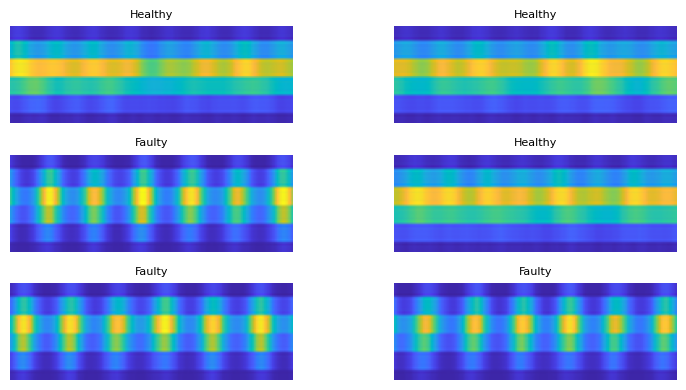

In [25]:
# visualize some training images
plt.figure(figsize=(8, 4))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(display_names[labels[i]], fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [26]:
# Q4(a): our model ("model 2" from the CNN lecture, lab work 2)
normalizer = tf.keras.layers.Normalization(axis=-1)   # normalize per channel (R,G,B)
normalizer.adapt(train_ds.map(lambda x, y: x))

fault_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_row, n_col, 3)),                       # 60x175x3
    normalizer,
    tf.keras.layers.Conv2D(8, 3, activation='relu'),                      # 58x173x8
    tf.keras.layers.MaxPooling2D(),                                       # 29x86x8
    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),                                       # 14x43x16
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),     # 14x43x32
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),                                       # 7x21x64
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),                                       # 3x10x64
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),                                       # 1x5x64
    tf.keras.layers.Flatten(),                                            # 320
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax'),
], name="our_model")
fault_model.summary()

Model: "our_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 60, 175, 3)       7         
 n)                                                              
                                                                 
 conv2d (Conv2D)             (None, 58, 173, 8)        224       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 29, 86, 8)        0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 86, 16)        1168      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 43, 16)       0         
 2D)                                                             
                                                         

In [27]:
EPOCHS = 15
fault_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

start_time = time.time()
history = fault_model.fit(train_ds, epochs=EPOCHS, verbose=2, validation_data=val_ds)
fault_train_time = time.time() - start_time
print(f"Training time: {fault_train_time:.1f} s")

validation_loss, validation_acc = fault_model.evaluate(val_ds)

Epoch 1/15
180/180 - 8s - loss: 0.2834 - accuracy: 0.9750 - val_loss: 0.1585 - val_accuracy: 1.0000 - 8s/epoch - 42ms/step
Epoch 2/15
180/180 - 7s - loss: 0.1395 - accuracy: 1.0000 - val_loss: 0.1252 - val_accuracy: 1.0000 - 7s/epoch - 37ms/step
Epoch 3/15
180/180 - 7s - loss: 0.1129 - accuracy: 1.0000 - val_loss: 0.1035 - val_accuracy: 1.0000 - 7s/epoch - 41ms/step
Epoch 4/15
180/180 - 9s - loss: 0.0972 - accuracy: 1.0000 - val_loss: 0.0915 - val_accuracy: 1.0000 - 9s/epoch - 48ms/step
Epoch 5/15
180/180 - 8s - loss: 0.0870 - accuracy: 1.0000 - val_loss: 0.0827 - val_accuracy: 1.0000 - 8s/epoch - 47ms/step
Epoch 6/15
180/180 - 8s - loss: 0.0791 - accuracy: 1.0000 - val_loss: 0.0756 - val_accuracy: 1.0000 - 8s/epoch - 45ms/step
Epoch 7/15
180/180 - 7s - loss: 0.0727 - accuracy: 1.0000 - val_loss: 0.0697 - val_accuracy: 1.0000 - 7s/epoch - 39ms/step
Epoch 8/15
180/180 - 7s - loss: 0.0673 - accuracy: 1.0000 - val_loss: 0.0649 - val_accuracy: 1.0000 - 7s/epoch - 37ms/step
Epoch 9/15
180/1

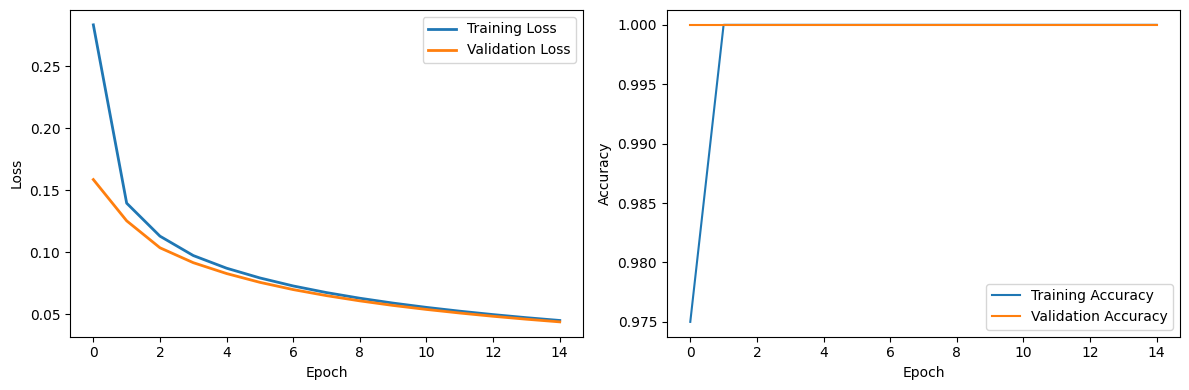

In [28]:
# Q4(b): train/val loss and accuracy
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

25/25 [==============================] - 0s 13ms/step - loss: 0.0619 - accuracy: 0.9900
Test accuracy:0.990 
 Test loss:0.062
25/25 [==============================] - 0s 13ms/step


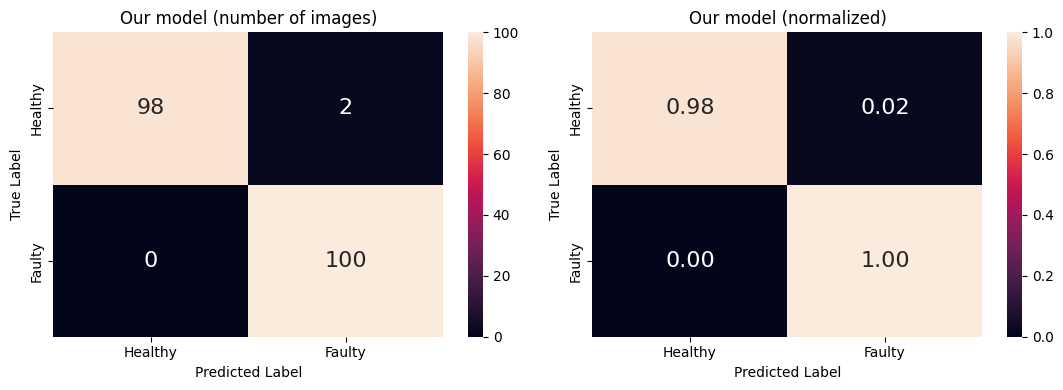

              precision    recall  f1-score   support

     Healthy      1.000     0.980     0.990       100
      Faulty      0.980     1.000     0.990       100

    accuracy                          0.990       200
   macro avg      0.990     0.990     0.990       200
weighted avg      0.990     0.990     0.990       200



In [29]:
# Q4(b): evaluate on the TEST set, as in the class notebook
test_loss, test_acc = fault_model.evaluate(test_ds)
print("Test accuracy:{:.3f} \n Test loss:{:.3f}".format(test_acc, test_loss))

# Get the predicted labels and true labels for the test set
start_time = time.time()
y_pred = np.argmax(fault_model.predict(test_ds), axis=-1)
fault_inference_ms = (time.time() - start_time) * 1000 / n_test   # ms per image
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Compute the confusion matrix, unnormalized and normalized
cm = confusion_matrix(y_true, y_pred)
cm_n = cm / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sn.heatmap(cm, xticklabels=display_names, yticklabels=display_names, annot=True, fmt='d', annot_kws={"size": 16})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Our model (number of images)')

plt.subplot(1, 2, 2)
sn.heatmap(cm_n, xticklabels=display_names, yticklabels=display_names, annot=True, fmt='.2f', annot_kws={"size": 16})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Our model (normalized)')
plt.tight_layout()
plt.show()

# classification report
report = classification_report(y_true, y_pred, target_names=display_names, digits=3)
print(report)

## Q4(c): Comparison with the class baseline

The baseline is the CNN from `fault-classification-class.ipynb`, copied unchanged and trained with the same settings
(Adam lr=1e-4, 15 epochs, batch size 8). Both models are evaluated on the same held-out test set. **Faulty** is the
positive class. For fault detection, **recall** matters most (lecture slide 169): a missed fault (false negative) is
the costly error.

In [30]:
# class baseline (fault-classification-class.ipynb)
baseline_normalizer = tf.keras.layers.Normalization(axis=-1)
baseline_normalizer.adapt(train_ds.map(lambda x, y: x))

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_row, n_col, 3)),
    baseline_normalizer,
    tf.keras.layers.Conv2D(4, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(8, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(8, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(16, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dense(64, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax'),
], name="class_baseline")

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
start_time = time.time()
baseline_history = baseline_model.fit(train_ds, epochs=EPOCHS, verbose=2, validation_data=val_ds)
baseline_train_time = time.time() - start_time

Epoch 1/15
180/180 - 4s - loss: 0.7475 - accuracy: 0.8472 - val_loss: 0.6526 - val_accuracy: 0.9750 - 4s/epoch - 24ms/step
Epoch 2/15
180/180 - 4s - loss: 0.5611 - accuracy: 0.9715 - val_loss: 0.4749 - val_accuracy: 0.9944 - 4s/epoch - 20ms/step
Epoch 3/15
180/180 - 4s - loss: 0.4213 - accuracy: 0.9944 - val_loss: 0.3488 - val_accuracy: 1.0000 - 4s/epoch - 20ms/step
Epoch 4/15
180/180 - 3s - loss: 0.3114 - accuracy: 0.9958 - val_loss: 0.2537 - val_accuracy: 1.0000 - 3s/epoch - 18ms/step
Epoch 5/15
180/180 - 3s - loss: 0.2275 - accuracy: 0.9951 - val_loss: 0.1865 - val_accuracy: 1.0000 - 3s/epoch - 19ms/step
Epoch 6/15
180/180 - 3s - loss: 0.1811 - accuracy: 0.9951 - val_loss: 0.1491 - val_accuracy: 1.0000 - 3s/epoch - 19ms/step
Epoch 7/15
180/180 - 3s - loss: 0.1445 - accuracy: 0.9993 - val_loss: 0.1239 - val_accuracy: 0.9972 - 3s/epoch - 19ms/step
Epoch 8/15
180/180 - 3s - loss: 0.1217 - accuracy: 0.9958 - val_loss: 0.1114 - val_accuracy: 1.0000 - 3s/epoch - 19ms/step
Epoch 9/15
180/1

25/25 [==============================] - 0s 10ms/step


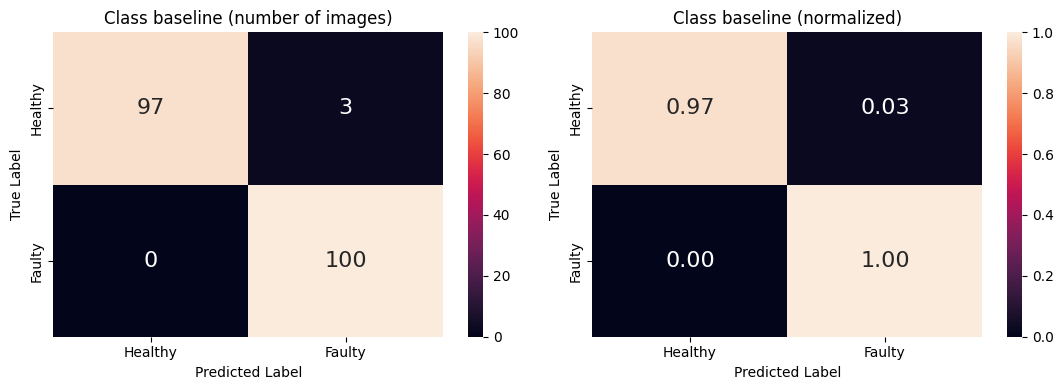

              precision    recall  f1-score   support

     Healthy      1.000     0.970     0.985       100
      Faulty      0.971     1.000     0.985       100

    accuracy                          0.985       200
   macro avg      0.985     0.985     0.985       200
weighted avg      0.985     0.985     0.985       200

         Model  Parameters  Training time (s)  Inference (ms/img)  Accuracy  Precision  Recall    F1
Class baseline        9339             52.829               1.818     0.985      0.971     1.0 0.985
     Our model      123225            106.847               2.376     0.990      0.980     1.0 0.990


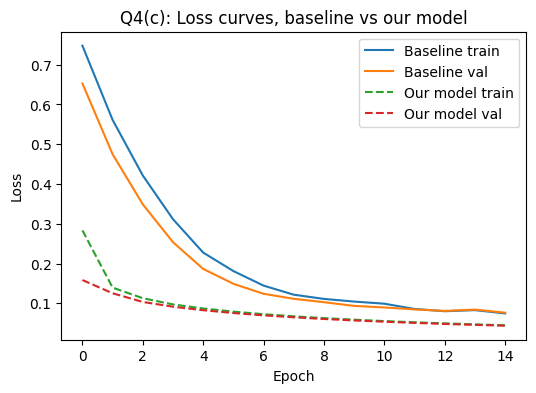

In [31]:
# evaluate the class baseline on the test set in the same way
start_time = time.time()
y_pred_baseline = np.argmax(baseline_model.predict(test_ds), axis=-1)
baseline_inference_ms = (time.time() - start_time) * 1000 / n_test

cm = confusion_matrix(y_true, y_pred_baseline)
cm_n = cm / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sn.heatmap(cm, xticklabels=display_names, yticklabels=display_names, annot=True, fmt='d', annot_kws={"size": 16})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Class baseline (number of images)')

plt.subplot(1, 2, 2)
sn.heatmap(cm_n, xticklabels=display_names, yticklabels=display_names, annot=True, fmt='.2f', annot_kws={"size": 16})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Class baseline (normalized)')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_baseline, target_names=display_names, digits=3))

# comparison table (lab work 3). Faulty = positive class (label 1)
comparison = pd.DataFrame({
    "Model": ["Class baseline", "Our model"],
    "Parameters": [baseline_model.count_params(), fault_model.count_params()],
    "Training time (s)": [baseline_train_time, fault_train_time],
    "Inference (ms/img)": [baseline_inference_ms, fault_inference_ms],
    "Accuracy": [accuracy_score(y_true, y_pred_baseline), accuracy_score(y_true, y_pred)],
    "Precision": [precision_score(y_true, y_pred_baseline), precision_score(y_true, y_pred)],
    "Recall": [recall_score(y_true, y_pred_baseline), recall_score(y_true, y_pred)],
    "F1": [f1_score(y_true, y_pred_baseline), f1_score(y_true, y_pred)],
})
print(comparison.round(3).to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(baseline_history.history['loss'], label='Baseline train')
plt.plot(baseline_history.history['val_loss'], label='Baseline val')
plt.plot(history.history['loss'], '--', label='Our model train')
plt.plot(history.history['val_loss'], '--', label='Our model val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Q4(c): Loss curves, baseline vs our model')
plt.legend()
plt.show()

# Q5. Classification on CIFAR-10

Follows the class notebook `classification-transferlearning-tuning-class.ipynb` (Keras, ImageNet-pretrained models,
32x32x3 input, `GlobalAveragePooling2D` + Dense head + softmax, Adam, sparse categorical cross-entropy).
CIFAR-10 images are already 32x32x3, so only `preprocess_input` is needed (no resizing as with MNIST).

- **(a) Model fusion:** features from two frozen pretrained models (MobileNetV2 + ResNet50, both on the
  feature-fusion slide) are concatenated, then a Dense head is trained on top.
- **(b) Transfer learning:** MobileNetV2 with all layers frozen, only the new head is trained.
- **(c) Fine-tuning:** MobileNetV2 with its last 30 layers unfrozen, trained with a lower learning rate.
- **(d) Comparison:** parameters, training time, inference time, accuracy, precision, recall, F1.

On a CPU, 10 000 of the 50 000 training images and 2 000 test images are used, with 5 epochs per model.

Train images shape: (10000, 32, 32, 3)
Test images shape: (2000, 32, 32, 3)


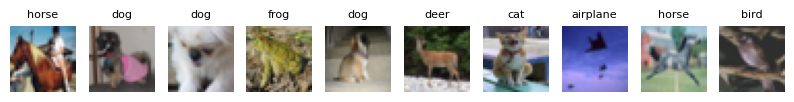

In [32]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sn
from tensorflow.keras.applications import MobileNetV2, ResNet50
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tf.keras.utils.set_random_seed(0)

# Load CIFAR-10 dataset (automatically downloads if needed)
(x_train_c, y_train_c), (x_test_c, y_test_c) = tf.keras.datasets.cifar10.load_data()
y_train_c = y_train_c.flatten()   # (50000, 1) -> (50000,)
y_test_c = y_test_c.flatten()

# random subset so training is feasible on a CPU
np.random.seed(0)
train_idx = np.random.choice(len(x_train_c), 10000, replace=False)
test_idx = np.random.choice(len(x_test_c), 2000, replace=False)
x_train_c, y_train_c = x_train_c[train_idx].astype('float32'), y_train_c[train_idx]
x_test_c, y_test_c = x_test_c[test_idx].astype('float32'), y_test_c[test_idx]

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Train images shape:", x_train_c.shape)
print("Test images shape:", x_test_c.shape)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_c[i].astype('uint8'))
    plt.title(cifar_classes[y_train_c[i]], fontsize=8)
    plt.axis('off')
plt.show()

# Normalize: each pretrained model expects its own input scaling
x_train_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input(x_train_c.copy())   # -> [-1, 1]
x_test_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input(x_test_c.copy())
x_train_resnet = tf.keras.applications.resnet50.preprocess_input(x_train_c.copy())        # BGR, mean subtracted
x_test_resnet = tf.keras.applications.resnet50.preprocess_input(x_test_c.copy())

EPOCHS_C = 5
BATCH_C = 32

In [33]:
# Q5(a): model fusion - MobileNetV2 and ResNet50 features are concatenated
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
mobilenet_base.trainable = False
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
resnet_base.trainable = False

input_mobilenet = tf.keras.Input(shape=(32, 32, 3))
input_resnet = tf.keras.Input(shape=(32, 32, 3))

features_mobilenet = tf.keras.layers.GlobalAveragePooling2D()(mobilenet_base(input_mobilenet, training=False))  # 1280
features_resnet = tf.keras.layers.GlobalAveragePooling2D()(resnet_base(input_resnet, training=False))           # 2048

x = tf.keras.layers.Concatenate()([features_mobilenet, features_resnet])   # 3328 fused features
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu')(x)
predictions = tf.keras.layers.Dense(10, activation='softmax')(x)  # last layer

fusion_model = tf.keras.models.Model(inputs=[input_mobilenet, input_resnet], outputs=predictions)

total_params = fusion_model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in fusion_model.trainable_weights])
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

fusion_model.compile(optimizer='adam', loss='SparseCategoricalCrossentropy', metrics=['accuracy'])

start_time = time.time()
fusion_history = fusion_model.fit(
    [x_train_mobilenet, x_train_resnet], y_train_c,
    batch_size=BATCH_C,
    validation_split=0.2,
    epochs=EPOCHS_C,
    verbose=2,
)
fusion_time = time.time() - start_time
print(f"Total training time: {fusion_time:.2f} seconds")

Total parameters: 26,061,162
Trainable parameters: 215,466
Epoch 1/5
250/250 - 32s - loss: 1.8225 - accuracy: 0.4655 - val_loss: 1.5876 - val_accuracy: 0.5500 - 32s/epoch - 126ms/step
Epoch 2/5
250/250 - 27s - loss: 1.3620 - accuracy: 0.6269 - val_loss: 1.4238 - val_accuracy: 0.5920 - 27s/epoch - 109ms/step
Epoch 3/5
250/250 - 28s - loss: 1.1363 - accuracy: 0.6894 - val_loss: 1.4145 - val_accuracy: 0.5975 - 28s/epoch - 111ms/step
Epoch 4/5
250/250 - 26s - loss: 0.9762 - accuracy: 0.7442 - val_loss: 1.3821 - val_accuracy: 0.6050 - 26s/epoch - 105ms/step
Epoch 5/5
250/250 - 30s - loss: 0.8539 - accuracy: 0.7839 - val_loss: 1.4369 - val_accuracy: 0.5925 - 30s/epoch - 118ms/step
Total training time: 142.55 seconds


In [34]:
# Q5(b): transfer learning - MobileNetV2 frozen, only the new layers are trained
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze base model. This ensures that the weights are frozen and not trained during training
base_model.trainable = False

inputs = tf.keras.Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu')(x)
predictions = tf.keras.layers.Dense(10, activation='softmax')(x)  # last layer

tl_model = tf.keras.models.Model(inputs=inputs, outputs=predictions)

total_params = tl_model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in tl_model.trainable_weights])
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

tl_model.compile(optimizer='adam', loss='SparseCategoricalCrossentropy', metrics=['accuracy'])

start_time = time.time()
tl_history = tl_model.fit(x_train_mobilenet, y_train_c, batch_size=BATCH_C, validation_split=0.2,
                          epochs=EPOCHS_C, verbose=2)
tl_time = time.time() - start_time
print(f"Total training time: {tl_time:.2f} seconds")

Total parameters: 2,342,378
Trainable parameters: 84,394
Epoch 1/5
250/250 - 11s - loss: 2.1673 - accuracy: 0.2167 - val_loss: 2.1100 - val_accuracy: 0.2515 - 11s/epoch - 44ms/step
Epoch 2/5
250/250 - 7s - loss: 2.0273 - accuracy: 0.2696 - val_loss: 2.0555 - val_accuracy: 0.2720 - 7s/epoch - 29ms/step
Epoch 3/5
250/250 - 7s - loss: 1.9714 - accuracy: 0.2903 - val_loss: 2.0312 - val_accuracy: 0.2710 - 7s/epoch - 29ms/step
Epoch 4/5
250/250 - 8s - loss: 1.9306 - accuracy: 0.3084 - val_loss: 2.0251 - val_accuracy: 0.2780 - 8s/epoch - 31ms/step
Epoch 5/5
250/250 - 10s - loss: 1.9005 - accuracy: 0.3219 - val_loss: 2.0163 - val_accuracy: 0.2820 - 10s/epoch - 38ms/step
Total training time: 42.84 seconds


In [35]:
# Q5(c): fine-tuning - the last 30 layers of MobileNetV2 are unfrozen and trained with a lower learning rate
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

inputs = tf.keras.Input(shape=(32, 32, 3))
# training=False keeps the BatchNorm statistics of MobileNetV2 fixed (only its weights are fine-tuned)
x = base_model(inputs, training=False)   # feature maps (1,1,1280)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activity_regularizer=tf.keras.regularizers.L2(0.01), activation='relu')(x)
predictions = tf.keras.layers.Dense(10, activation='softmax')(x)  # last layer

ft_model = tf.keras.models.Model(inputs=inputs, outputs=predictions)

total_params = ft_model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in ft_model.trainable_weights])
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

ft_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                 loss='SparseCategoricalCrossentropy', metrics=['accuracy'])

start_time = time.time()
ft_history = ft_model.fit(x_train_mobilenet, y_train_c, batch_size=BATCH_C, validation_split=0.2,
                          epochs=EPOCHS_C, verbose=2)
ft_time = time.time() - start_time
print(f"Total training time: {ft_time:.2f} seconds")

Total parameters: 2,342,378
Trainable parameters: 1,610,794
Epoch 1/5
250/250 - 15s - loss: 2.0957 - accuracy: 0.2786 - val_loss: 1.8964 - val_accuracy: 0.3550 - 15s/epoch - 60ms/step
Epoch 2/5
250/250 - 10s - loss: 1.7821 - accuracy: 0.4109 - val_loss: 1.6949 - val_accuracy: 0.4370 - 10s/epoch - 41ms/step
Epoch 3/5
250/250 - 10s - loss: 1.6237 - accuracy: 0.4830 - val_loss: 1.5961 - val_accuracy: 0.5070 - 10s/epoch - 40ms/step
Epoch 4/5
250/250 - 12s - loss: 1.5335 - accuracy: 0.5345 - val_loss: 1.5067 - val_accuracy: 0.5515 - 12s/epoch - 48ms/step
Epoch 5/5
250/250 - 10s - loss: 1.4414 - accuracy: 0.5719 - val_loss: 1.4384 - val_accuracy: 0.5685 - 10s/epoch - 39ms/step
Total training time: 57.24 seconds


63/63 [==============================] - 2s 22ms/step
               Method  Parameters  Trainable  Training time (s)  Inference (ms/img)  Accuracy  Precision  Recall    F1
     (a) Model fusion    26061162     215466            142.553               3.306     0.582      0.593   0.585 0.584
(b) Transfer learning     2342378      84394             42.837               0.962     0.275      0.295   0.275 0.255
      (c) Fine-tuning     2342378    1610794             57.242               0.928     0.549      0.551   0.554 0.544


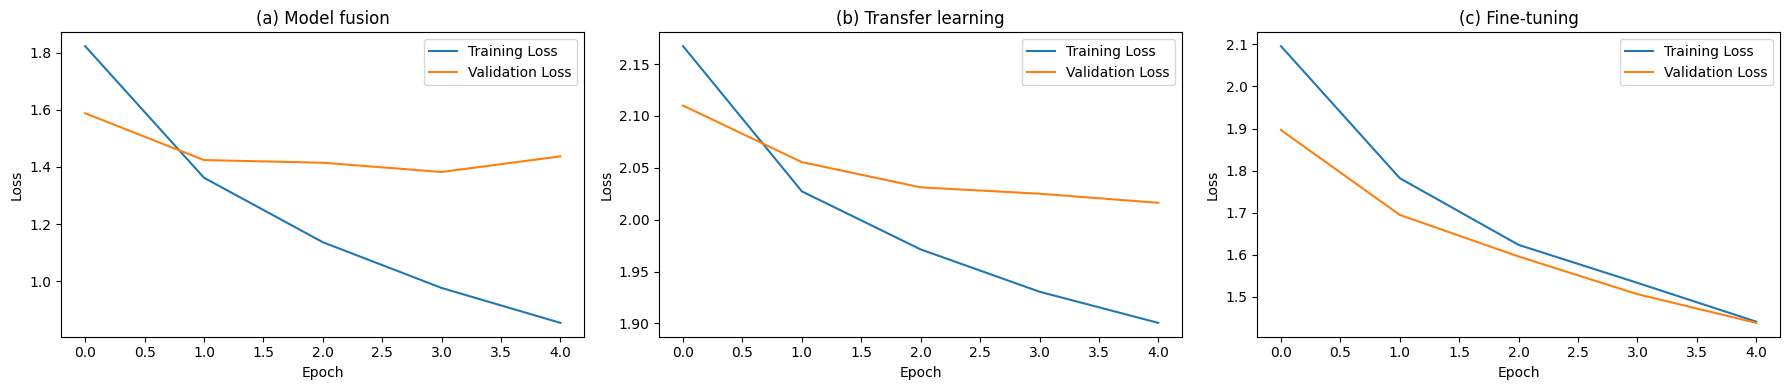

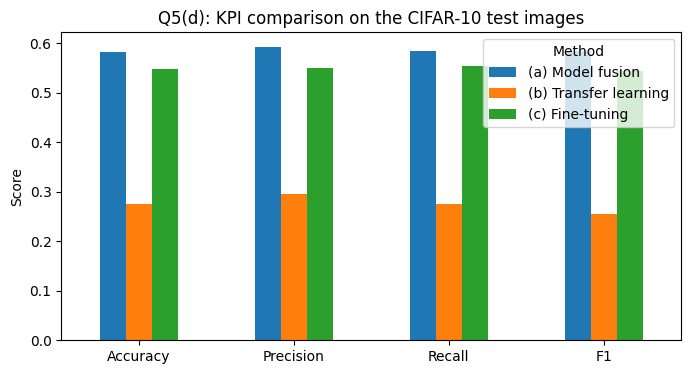

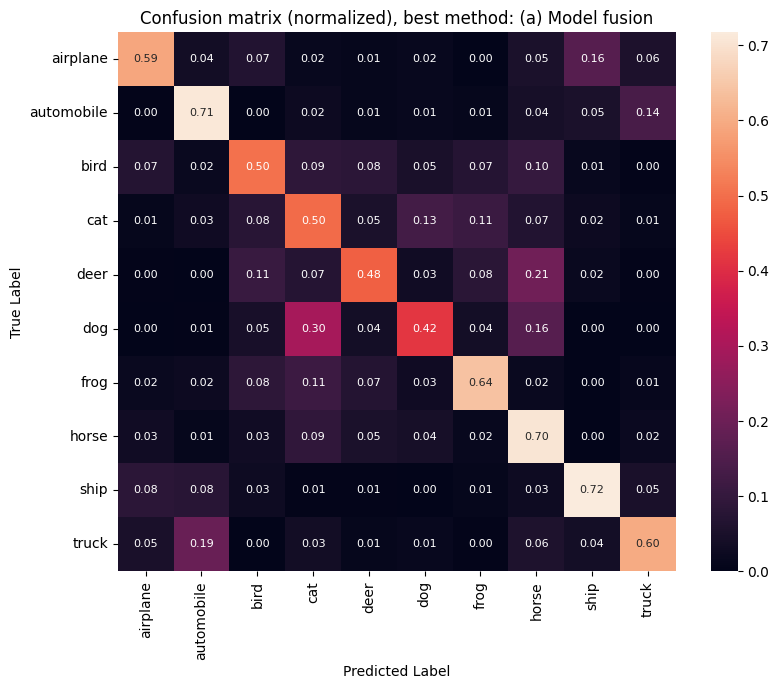

              precision    recall  f1-score   support

    airplane      0.692     0.591     0.638       198
  automobile      0.664     0.710     0.686       214
        bird      0.542     0.502     0.521       207
         cat      0.419     0.495     0.454       210
        deer      0.626     0.478     0.542       224
         dog      0.548     0.417     0.473       192
        frog      0.616     0.640     0.628       178
       horse      0.468     0.704     0.562       189
        ship      0.677     0.717     0.697       184
       truck      0.674     0.598     0.634       204

    accuracy                          0.583      2000
   macro avg      0.593     0.585     0.584      2000
weighted avg      0.592     0.583     0.582      2000



In [36]:
# Q5(d): comparison of (a)-(c) on the test images
# precision, recall and F1 are macro averages: the mean over the 10 classes ("macro avg" in classification_report)
methods = ["(a) Model fusion", "(b) Transfer learning", "(c) Fine-tuning"]
models = [fusion_model, tl_model, ft_model]
test_inputs = [[x_test_mobilenet, x_test_resnet], x_test_mobilenet, x_test_mobilenet]
histories = [fusion_history, tl_history, ft_history]
train_times = [fusion_time, tl_time, ft_time]

predictions_test = []
inference_ms = []
for model_, x_test_input in zip(models, test_inputs):
    start_time = time.time()
    predictions_test.append(np.argmax(model_.predict(x_test_input), axis=-1))
    inference_ms.append((time.time() - start_time) * 1000 / len(y_test_c))

comparison_c = pd.DataFrame({
    "Method": methods,
    "Parameters": [m.count_params() for m in models],
    "Trainable": [sum([tf.keras.backend.count_params(w) for w in m.trainable_weights]) for m in models],
    "Training time (s)": train_times,
    "Inference (ms/img)": inference_ms,
    "Accuracy": [accuracy_score(y_test_c, p) for p in predictions_test],
    "Precision": [precision_score(y_test_c, p, average='macro') for p in predictions_test],
    "Recall": [recall_score(y_test_c, p, average='macro') for p in predictions_test],
    "F1": [f1_score(y_test_c, p, average='macro') for p in predictions_test],
})
print(comparison_c.round(3).to_string(index=False))

# train/val loss of each method
plt.figure(figsize=(18, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(histories[i].history['loss'], label='Training Loss')
    plt.plot(histories[i].history['val_loss'], label='Validation Loss')
    plt.title(methods[i])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# KPI bar chart
kpis = ["Accuracy", "Precision", "Recall", "F1"]
comparison_c.set_index("Method")[kpis].T.plot.bar(figsize=(8, 4), rot=0)
plt.ylabel("Score")
plt.title("Q5(d): KPI comparison on the CIFAR-10 test images")
plt.show()

# confusion matrix and classification report of the best method (highest F1)
best = int(np.argmax(comparison_c["F1"]))
cm = confusion_matrix(y_test_c, predictions_test[best])
cm_n = cm / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(9, 7))
sn.heatmap(cm_n, xticklabels=cifar_classes, yticklabels=cifar_classes, annot=True, fmt='.2f', annot_kws={"size": 8})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f"Confusion matrix (normalized), best method: {methods[best]}")
plt.show()
print(classification_report(y_test_c, predictions_test[best], target_names=cifar_classes, digits=3))

# Q6. Autoencoder on fault-classification-class

Follows the class notebook `autoencoder-class.ipynb`: a Dense autoencoder with a 32-value latent space
(`Dense(32, relu)` encoder, `Dense(input_dim, sigmoid)` decoder, Adam, binary cross-entropy). Each 60x175x3 image is
flattened to 31 500 values, which gives about 984x compression. The model is trained on the training images of both
classes, with the test images used as validation. The reconstruction error is measured with the four metrics from the
notebook exercise: **MSE, MAE, SSIM and PSNR** (`skimage.metrics`).

In the latent-vector row, black entries are latent units that are exactly 0. With a ReLU bottleneck (as in the
class notebook), some of the 32 units stay inactive ("dying ReLU", lecture slide 81), so the images are encoded by
the few active units.

Found 1800 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
(1800, 31500) (200, 31500)
Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 31500)]           0         
                                                                 
 dense_18 (Dense)            (None, 32)                1008032   
                                                                 
 dense_19 (Dense)            (None, 31500)             1039500   
                                                                 
Total params: 2,047,532
Trainable params: 2,047,532
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
57/57 - 2s - loss: 0.5622 - mse: 0.0293 - val_loss: 0.5282 - val_mse: 0.0143 - 2s/epoch - 43ms/step
Epoch 2/50
57/57 - 2s - loss: 0.5204 - mse: 0.0112 - val_loss: 0.5081 - val_mse: 0.0061 - 2s/e

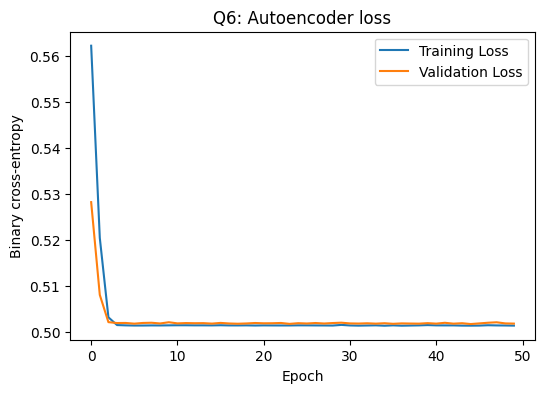

In [37]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

tf.keras.utils.set_random_seed(0)


def load_images(directory):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        str(directory), labels='inferred', color_mode='rgb', batch_size=32, image_size=image_size, shuffle=False)
    x = np.concatenate([x.numpy() for x, y in ds], axis=0).astype('float32') / 255.
    y = np.concatenate([y.numpy() for x, y in ds], axis=0)
    return x, y


x_train_img, y_train_ae = load_images(FAULT_DATA_ROOT / "training")
x_test_img, y_test_ae = load_images(FAULT_DATA_ROOT / "testing")

img_shape = x_train_img.shape[1:]      # (60, 175, 3)
input_dim = int(np.prod(img_shape))    # 31500
x_train_ae = x_train_img.reshape((len(x_train_img), input_dim))
x_test_ae = x_test_img.reshape((len(x_test_img), input_dim))
print(x_train_ae.shape, x_test_ae.shape)

# This is the size of our encoded representations
encoding_dim = 32

input_img = tf.keras.Input(shape=(input_dim,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(input_dim, activation='sigmoid')(encoded)

encoder = tf.keras.Model(input_img, encoded)
autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])
autoencoder.summary()

ae_history = autoencoder.fit(x_train_ae, x_train_ae,
                             epochs=50,
                             batch_size=32,
                             shuffle=True,
                             validation_data=(x_test_ae, x_test_ae),
                             verbose=2)

decoder_input = tf.keras.layers.Input(shape=(encoding_dim,))
decoder = tf.keras.Model(decoder_input, autoencoder.layers[-1](decoder_input))

plt.figure(figsize=(6, 4))
plt.plot(ae_history.history['loss'], label='Training Loss')
plt.plot(ae_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy')
plt.title('Q6: Autoencoder loss')
plt.legend()
plt.show()

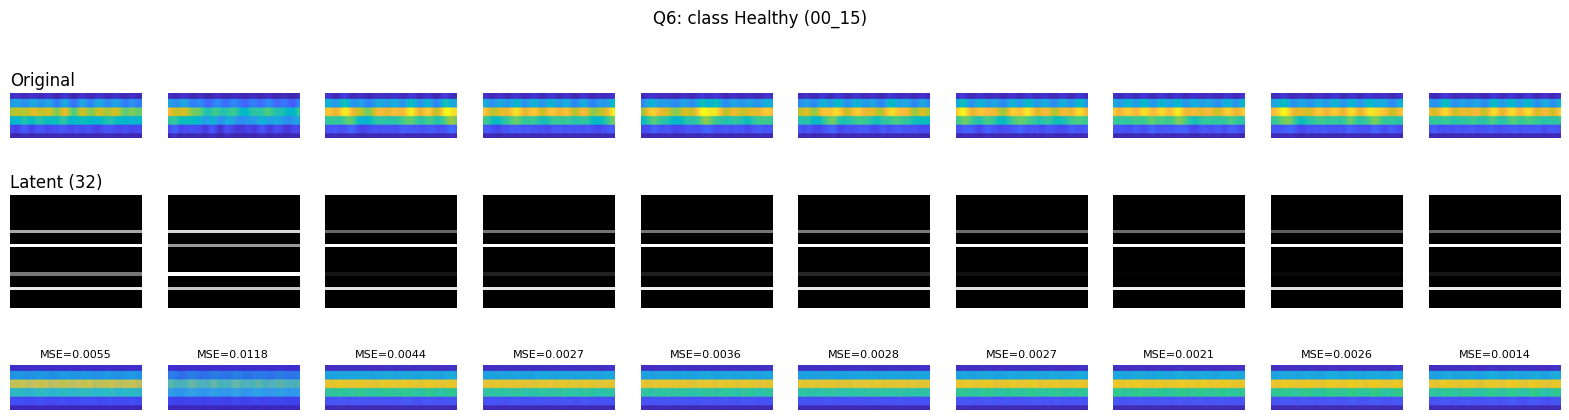

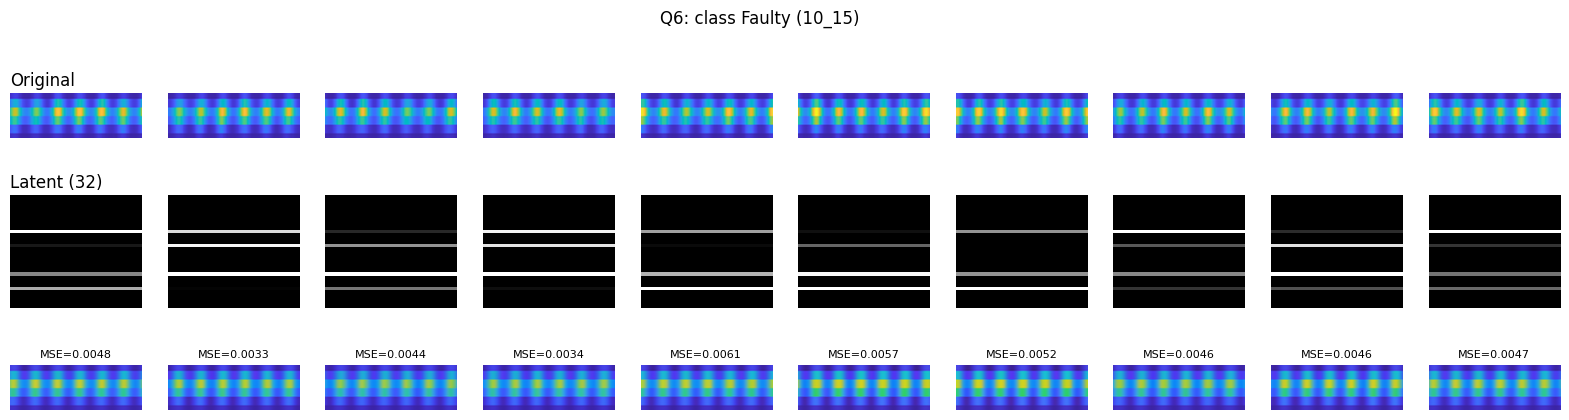

In [38]:
# Q6(a)-(c): original, latent vector and reconstruction for 10 random test images per class
np.random.seed(0)
ae_errors = {}

for label, name in enumerate(display_names):
    idx = np.random.choice(np.where(y_test_ae == label)[0], 10, replace=False)
    encoded_imgs = encoder.predict(x_test_ae[idx], verbose=0)        # 10x32
    decoded_imgs = decoder.predict(encoded_imgs, verbose=0)          # 10x31500

    originals = x_test_ae[idx].reshape((-1,) + img_shape)
    reconstructions = decoded_imgs.reshape((-1,) + img_shape)
    ae_errors[name] = {
        "MSE": np.mean((originals - reconstructions) ** 2, axis=(1, 2, 3)),
        "MAE": np.mean(np.abs(originals - reconstructions), axis=(1, 2, 3)),
        "SSIM": np.array([structural_similarity(o, r, channel_axis=2, data_range=1.0)
                          for o, r in zip(originals, reconstructions)]),
        "PSNR": np.array([peak_signal_noise_ratio(o, r, data_range=1.0)
                          for o, r in zip(originals, reconstructions)]),
    }

    n = 10
    plt.figure(figsize=(20, 5))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)                  # original
        plt.imshow(originals[i])
        ax.axis('off')
        if i == 0:
            ax.set_title("Original", loc='left')

        ax = plt.subplot(3, n, i + 1 + n)              # latent vector (32 values)
        plt.imshow(encoded_imgs[i].reshape(encoding_dim, 1), aspect='auto', cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title("Latent (32)", loc='left')

        ax = plt.subplot(3, n, i + 1 + 2 * n)          # reconstruction
        plt.imshow(reconstructions[i])
        ax.set_title(f"MSE={ae_errors[name]['MSE'][i]:.4f}", fontsize=8)
        ax.axis('off')
    plt.suptitle(f"Q6: class {name} ({class_names[label]})")
    plt.show()


Class Healthy: per-image reconstruction error
image         MSE       MAE      SSIM      PSNR
0          0.0055    0.0456    0.8537   22.6013
1          0.0118    0.0658    0.7414   19.2758
2          0.0044    0.0390    0.8402   23.5987
3          0.0027    0.0326    0.8755   25.7058
4          0.0036    0.0364    0.8733   24.3822
5          0.0028    0.0336    0.8737   25.5037
6          0.0027    0.0347    0.8541   25.6136
7          0.0021    0.0309    0.8761   26.7515
8          0.0026    0.0323    0.8697   25.8458
9          0.0014    0.0260    0.8868   28.5907
mean       0.0040    0.0377    0.8545   24.7869

Class Faulty: per-image reconstruction error
image         MSE       MAE      SSIM      PSNR
0          0.0048    0.0419    0.8081   23.2060
1          0.0033    0.0355    0.8220   24.7982
2          0.0044    0.0418    0.7844   23.5327
3          0.0034    0.0371    0.8175   24.6846
4          0.0061    0.0473    0.7728   22.1599
5          0.0057    0.0461    0.7733   22.

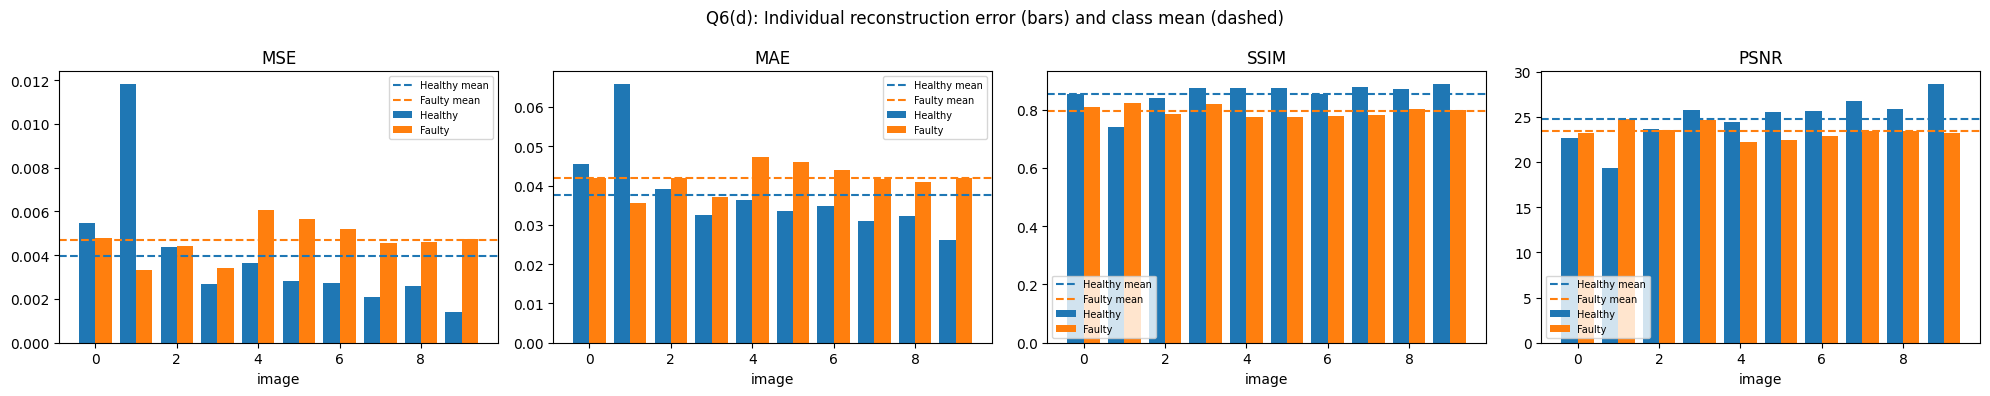

In [39]:
# Q6(d): individual reconstruction error and mean per class
metric_names = ["MSE", "MAE", "SSIM", "PSNR"]

for name in display_names:
    print(f"\nClass {name}: per-image reconstruction error")
    print(f"{'image':<7}" + "".join(f"{m:>10}" for m in metric_names))
    for i in range(10):
        print(f"{i:<7}" + "".join(f"{ae_errors[name][m][i]:>10.4f}" for m in metric_names))
    print(f"{'mean':<7}" + "".join(f"{ae_errors[name][m].mean():>10.4f}" for m in metric_names))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, m in zip(axes, metric_names):
    for offset, name in zip([-0.2, 0.2], display_names):
        values = ae_errors[name][m]
        bars = ax.bar(np.arange(10) + offset, values, 0.4, label=name)
        ax.axhline(values.mean(), linestyle='--', color=bars[0].get_facecolor(), label=f"{name} mean")
    ax.set_title(m)
    ax.set_xlabel("image")
    ax.legend(fontsize=7)
plt.suptitle("Q6(d): Individual reconstruction error (bars) and class mean (dashed)")
plt.tight_layout()
plt.show()